In [1]:
# Chargement de la librairie rootSolve
library(rootSolve)

Y ~ N($\theta$, $\sigma ^2$) avec $\sigma^2$ = 1 

$\theta$ ~ N(b, $d^2$) avec $d^2$ = 10, b = 5

r = $\frac{f( \theta ^* | y)}{( \theta_i | y)}  
= \frac{f( \theta ^*)}{( \theta_i)} 
\frac{ \prod_{k=1}^5{f( y_k | \theta ^*)} }{ \prod_{k=1}^5{f( y_k | \theta _i)} }$

-> ln(r) = $ln(f( \theta^*)) - ln(\theta_i) + \sum_{k=1}*5{ln(f(y_k | \theta^*))} - \sum_{k=1}*5{ln(f(y_k | \theta_i))}$





In [2]:
# Variables du problème
y = c(9.37, 10.18, 9.16, 11.60, 10.33)
sig2 = 1; d2 = 10; b = 5; n=5
mu = (b/d2 + sum(y)/sig2)/(1/d2 + n/sig2)
sig2_post = (1/d2 + n/sig2)^-1

In [3]:
mu; sig2_post

[1] 10.02745

[1] 0.1960784

In [4]:
# algorithme de Metropolis-Hastings
metropolis_hastings <- function(y, sigma2, d2, b, n_iter, theta_init, prop_sd) {
  n <- length(y)
  theta <- numeric(n_iter)
  theta[1] <- theta_init

  # Densité prior: N(b, d2)
  log_prior <- function(theta) {
    dnorm(theta, mean=b, sd=sqrt(d2), log=TRUE)
  }

  # Densité de vraisemblance: produit des N(theta, sigma2)
  log_likelihood <- function(theta) {
    sum(dnorm(y, mean=theta, sd=sqrt(sigma2), log=TRUE))
  }

  for (i in 2:n_iter) {
    # Proposer une nouvelle valeur (random walk : normale centrée sur la valeur actuelle)
    theta_proposal <- rnorm(1, mean=theta[i-1], sd=prop_sd)

    # Calcul de log(r)
    log_r <- log_prior(theta_proposal) + log_likelihood(theta_proposal) -
             log_prior(theta[i-1]) - log_likelihood(theta[i-1])
    
    # Acceptation/rejet
    if (log(runif(1)) < log_r) {
      theta[i] <- theta_proposal
    } else {
      theta[i] <- theta[i-1]
    }
  }

  return(theta)
}

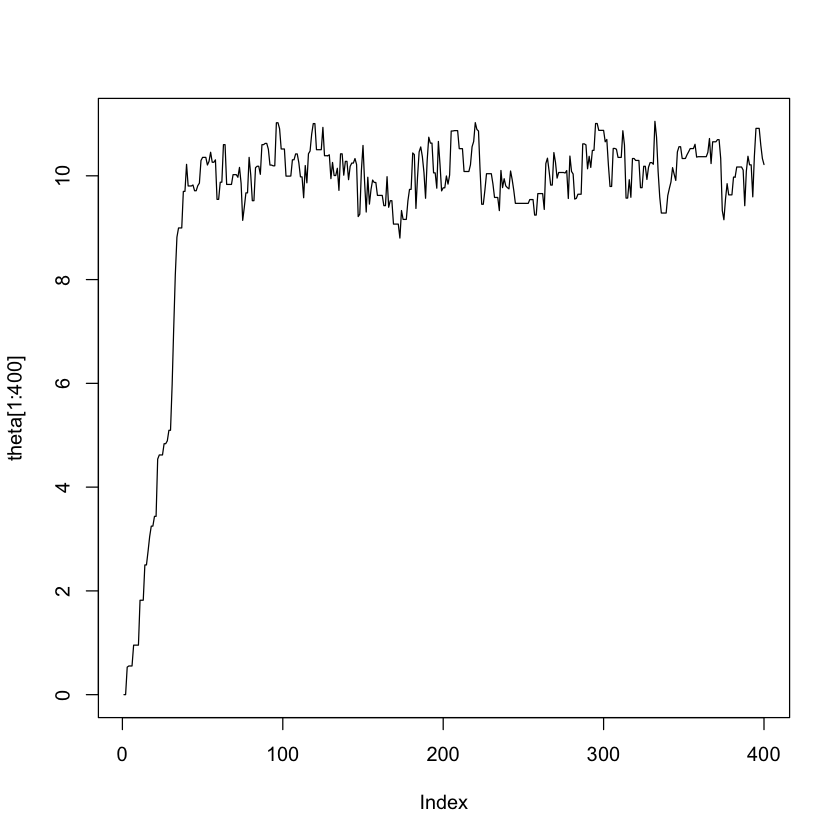

In [7]:
theta = metropolis_hastings(y, sig2, d2, b, 10000, 0, 0.5)
plot(theta[1:400], type="l")

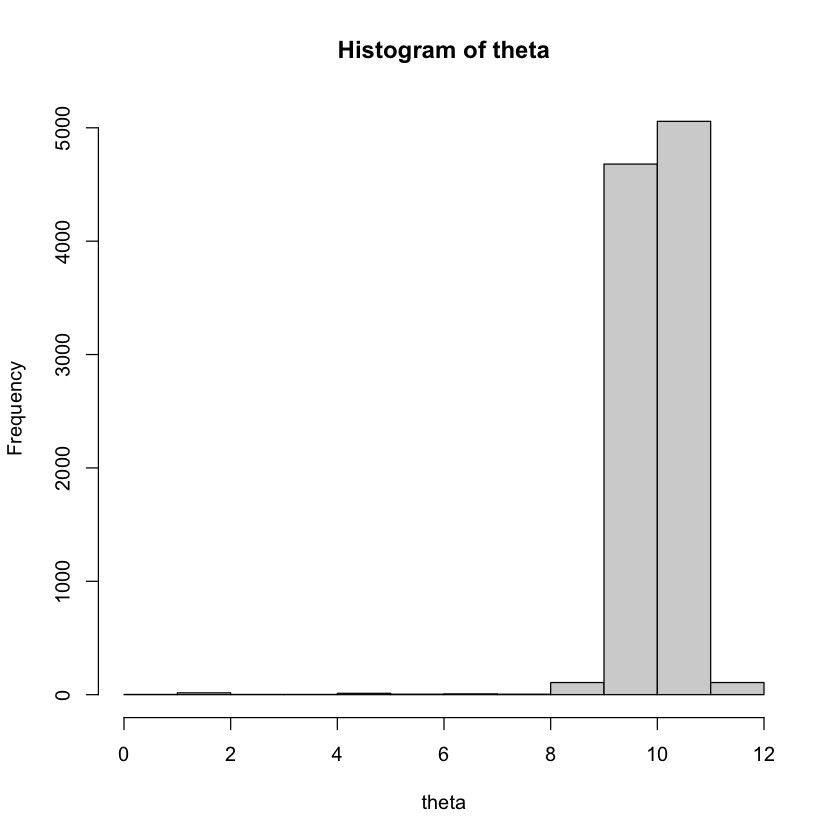

In [6]:
hist(theta)